<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #44a305 solid;
                   background-color:#F4F9E6;
                   color:#6ba340;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #44a305 solid;
                   background-color:#F4F9E6;
                   color:#6ba340;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Métodos Numéricos
        </td>
        <td style="border: 1px #44a305 solid;
                   background-color:#F4F9E6;
                   color:#6ba340;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 21 - Método de Ostrowski
        </td>
    </tr>
    <tr>
 

</table>

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Método de Ostrowski

In [2]:
def Ostrowski(f,df,x0,tol,maxiter):
    iters = 0
    error = tol+1
    error_x = list()

    while error>tol and iters<=maxiter:
        y = x0-f(x0)/df(x0)
        x = y-f(x0)/(f(x0)-2*f(y))*f(y)/df(x0)
        error = math.fabs(x-x0)
        error_x.append(error)
        iters = iters+1
        x0 = x

    error_x = np.array(error_x)
    ACOC = np.log(error_x[2:]/error_x[1:-1])/np.log(error_x[1:-1]/error_x[0:-2])

    return [x,iters,error,ACOC]

## Método de Ostrowski con Tabla

In [3]:
def Ostrowskitabla(f,df,x0,tol,maxiter):
    iters = 0
    error = tol+1
    lista_x = list(); lista_e = list() #Se crean listas para x y el error

    while error>tol and iters<=maxiter:
        y = x0-f(x0)/df(x0)
        x = y-f(x0)/(f(x0)-2*f(y))*f(y)/df(x0)
        error = math.fabs(x-x0)
        iters = iters+1
        x0 = x
        lista_x.append(x); lista_e.append(error);
    tabla = pd.DataFrame({'Iteraciones': lista_x, 'Error': lista_e}) #Se crear el dataframe
    pd.set_option('display.precision', 12)
    return tabla

## Ejemplo 1
Resolver la ecuación no lineal
$$2+(x-1)^3+e^{x^2}=0$$
Usando el método de Ostrowski con $x_0=-1$ y una tolerancia de $10^{-10}$

In [4]:
##Introducir f
f = lambda x: 2+(x-1)**3+math.exp(x**2)

#Introducir df
df = lambda x: 3*(x-1)**2+math.exp(x**2)*2*x

x0 = -1
tol = 1e-10
maxiter = 30

x,iters,error,ACOC = Ostrowski(f,df,x0,tol,maxiter)

In [5]:
print("La solución a la ecuacion es x = %s" %x)
print("El numero de iteraciones fue de %s" %iters)
print("El error que se tuvo fue %s" %error)
print("El vector del ACOC es %s" %ACOC)

La solución a la ecuacion es x = -0.48322324875500755
El numero de iteraciones fue de 3
El error que se tuvo fue 2.911781926684398e-12
El vector del ACOC es [3.70831891]


In [6]:
Ostrowskitabla(f,df,x0,tol,maxiter)

,Iteraciones,Error
0,-0.485325586654,0.514674413346
1,-0.483223248758,0.002102337896
2,-0.483223248755,0.000000000003


## Ejemplo 2

Se considera la ecuación
$$\ln (x^2+2)-x^3+1=0$$

- Realizar una representación gráfica para averiguar el número de soluciones y obtener una estimación inicial de las mismas.
- Resolver aplicando el método de Ostrowski con una tolerancia de $10^{-10}$.


<function matplotlib.pyplot.show(close=None, block=None)>

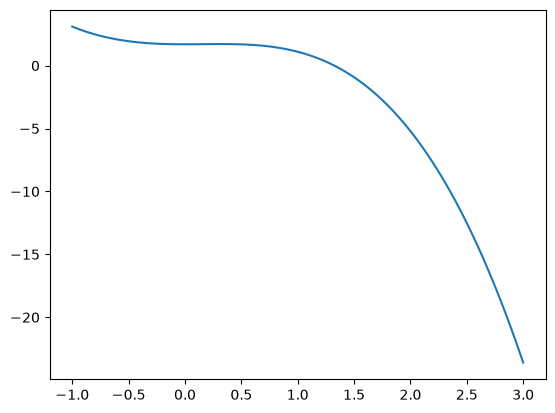

In [7]:
## graficamos la funcion

x= np.linspace(-1,3,100)
y = np.log(x**2+2)-x**3+1

plt.Figure
plt.plot(x,y)
plt.show

In [8]:
## la estimacion inical es x0 = 1



## Ejemplo 3

En ingeniería oceanográfica, la ecuación de una ola reflejada en un puerto está dada por $\lambda =16$, $t=12$ y $v=48$
$$h=\sin \left(\dfrac{2\pi x}{\lambda}  \right)\cos \left(\dfrac{2\pi tv}{\lambda} \right)+e^{-x}$$
Resolver para el valor positivo más bajo de $x$ si $h=0.5$.